In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import plotly.graph_objects as go  
from tensorflow import keras 
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, RepeatVector
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam
from keras.models import load_model
import random

2026-01-03 11:26:47.360588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-03 11:26:47.361970: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-03 11:26:47.365547: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-03 11:26:47.376163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767439607.394261  403116 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767439607.39

## Lectura de datos

In [2]:
# Semillas
np.random.seed(42)  
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
random.seed(42)

# Lectura de datos
train = pd.read_csv("../data/train_Flash_Semisupervisado.csv")
validation = pd.read_csv("../data/validation_Flash_Semisupervisado.csv")
test = pd.read_csv("../data/test_Flash_Semisupervisado.csv")

train = train[["interval", "spikes"]]
validation = validation[["interval", "spikes"]]
test = test[["interval", "spikes"]]

train.shape, validation.shape, test.shape

((2880, 2), (540, 2), (540, 2))

In [3]:
# Normalización de los datos
scaler = StandardScaler()
scaler = scaler.fit(train[["spikes"]])

train["spikes"] = scaler.transform(train[["spikes"]])
validation["spikes"] = scaler.transform(validation[["spikes"]])
test["spikes"] = scaler.transform(test[["spikes"]])

In [4]:
# Preparación de los datos para pasárselos a la red LSTM Autoencoder
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X)-time_steps):
        # Crea secuencias de TIME_STEPS valores y las guarda en un array de arrays
        Xs.append(X.iloc[i:(i+time_steps)].values)
        # Guarda el valor objetivo correspondiente = el siguiente
        ys.append(y.iloc[i+time_steps])

    return np.array(Xs), np.array(ys)

TIME_STEPS = 3

X_train, y_train = create_sequences(train[["spikes"]], train["spikes"], TIME_STEPS)
X_validation, y_validation = create_sequences(validation[["spikes"]], validation["spikes"], TIME_STEPS)
X_test, y_test = create_sequences(test[["spikes"]], test["spikes"], TIME_STEPS)

# Tendrá el formato [samples, TIME_STEPS, features]
print(f'Training shape: {X_train.shape}')
print(f'Validation shape: {X_validation.shape}')
print(f'Testing shape: {X_test.shape}')

Training shape: (2877, 3, 1)
Validation shape: (537, 3, 1)
Testing shape: (537, 3, 1)


In [5]:
# Para posteriormente evaluar el conjunto de entranimientos total (train + validation)
train_total = pd.concat([train, validation], axis=0).reset_index(drop=True)
X_train_total, y_train_total = create_sequences(train_total[["spikes"]], train_total["spikes"], TIME_STEPS)
print(f'Total training shape: {X_train_total.shape}')

Total training shape: (3417, 3, 1)


## Búsqueda de hiperparámetros

### Determinación de la arquitectura de la red

In [7]:
# -------------------------------------------------
# Fijar semillas para reproducibilidad
# -------------------------------------------------
def set_all_seeds(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    random.seed(seed)

# -------------------------------------------------
# Construcción explícita del modelo LSTM Autoencoder
# (permitiendo distinto número de neuronas por capa)
# -------------------------------------------------
def build_model(units_per_layer, dropout_rate, input_shape, learning_rate):

    model = Sequential()
    n_layers = len(units_per_layer)

    for i, units in enumerate(units_per_layer):

        # Todas las capas menos la última devuelven secuencias
        return_sequences = i < n_layers - 1

        # La primera capa necesita input_shape
        if i == 0:
            model.add(
                LSTM(
                    units=units,
                    activation="relu",
                    return_sequences=return_sequences,
                    input_shape=input_shape
                )
            )
        else:
            model.add(
                LSTM(
                    units=units,
                    activation="relu",
                    return_sequences=return_sequences
                )
            )

        # Dropout opcional tras cada capa LSTM
        if dropout_rate is not None:
            model.add(Dropout(dropout_rate))

    # Capa de salida (reconstrucción)
    model.add(Dense(input_shape[1]))

    # Compilación
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")

    return model

# -------------------------------------------------
# Arquitecturas a evaluar (mezcla de neuronas)
# -------------------------------------------------
architectures = [
    [8],
    [16],
    [32],
    [64],

    [8, 8],
    [16, 16],
    [32, 16],
    [64, 32],

    [8, 8, 8],
    [16, 16, 16],
    [32, 16, 8],
    [64, 32, 16],

    [64, 32, 16, 8]
]

# -------------------------------------------------
# Parámetros de la búsqueda
# -------------------------------------------------
dropout_options = [0.2, 0.5]

epochs = 15
batch_size = 64
learning_rate = 0.01
seed = 42

input_shape = (X_train.shape[1], X_train.shape[2])

# -------------------------------------------------
# Búsqueda de hiperparámetros
# -------------------------------------------------
best_val_loss = np.inf
best_config = None
best_model = None
best_history = None

for units_per_layer in architectures:
    for dropout_rate in dropout_options:

        print(
            f"Probando arquitectura -> "
            f"capas LSTM: {units_per_layer}, "
            f"dropout: {dropout_rate}"
        )

        # Fijar semillas antes de cada entrenamiento
        set_all_seeds(seed)

        # Construcción del modelo
        model = build_model(
            units_per_layer=units_per_layer,
            dropout_rate=dropout_rate,
            input_shape=input_shape,
            learning_rate=learning_rate
        )

        # Entrenamiento
        history = model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            validation_data=(X_validation, y_validation),
            verbose=0
        )

        # Mejor pérdida de validación
        min_val_loss = min(history.history["val_loss"])
        print(f" -> Mejor val_loss: {min_val_loss:.6f}")

        # Guardar la mejor configuración
        if min_val_loss < best_val_loss:
            best_val_loss = min_val_loss
            best_config = {
                "units_per_layer": units_per_layer,
                "dropout_rate": dropout_rate
            }
            best_model = model
            best_history = history

# -------------------------------------------------
# Resultados finales
# -------------------------------------------------
print("\n===================================")
print("MEJOR CONFIGURACIÓN ENCONTRADA")
print(best_config)
print(f"Mejor val_loss: {best_val_loss:.6f}")
print("===================================")

Probando arquitectura -> capas LSTM: [8], dropout: 0.2


W0000 00:00:1767090645.753707  310763 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/sergiolb/anaconda3/envs/Maria/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 -> Mejor val_loss: 0.596778
Probando arquitectura -> capas LSTM: [8], dropout: 0.5
 -> Mejor val_loss: 0.659770
Probando arquitectura -> capas LSTM: [16], dropout: 0.2
 -> Mejor val_loss: 0.582956
Probando arquitectura -> capas LSTM: [16], dropout: 0.5
 -> Mejor val_loss: 0.657407
Probando arquitectura -> capas LSTM: [32], dropout: 0.2
 -> Mejor val_loss: 0.576169
Probando arquitectura -> capas LSTM: [32], dropout: 0.5
 -> Mejor val_loss: 0.577100
Probando arquitectura -> capas LSTM: [64], dropout: 0.2
 -> Mejor val_loss: 0.596518
Probando arquitectura -> capas LSTM: [64], dropout: 0.5
 -> Mejor val_loss: 0.607113
Probando arquitectura -> capas LSTM: [8, 8], dropout: 0.2
 -> Mejor val_loss: 0.549975
Probando arquitectura -> capas LSTM: [8, 8], dropout: 0.5
 -> Mejor val_loss: 0.814695
Probando arquitectura -> capas LSTM: [16, 16], dropout: 0.2
 -> Mejor val_loss: 0.521106
Probando arquitectura -> capas LSTM: [16, 16], dropout: 0.5
 -> Mejor val_loss: 0.627042
Probando arquitectura -> 

### Determinación de función de activación capa intermedia y BS

In [12]:
# -------------------------------------------------
# Valores a explorar
# -------------------------------------------------
activaciones = ["relu", "sigmoid", "tanh"]
batch_sizes = [32, 64, 128]

# Arquitectura base (mejor encontrada previamente)
best_units_per_layer = [8, 8, 8]
best_dropout = 0.2
learning_rate = 0.01
epochs = 15

best_val_loss = float("inf")
best_model = None
best_combo = None

# -------------------------------------------------
# Búsqueda sobre batch_size, loss y activation
# -------------------------------------------------
for activation_fn in activaciones:
    for bs in batch_sizes:

        print(f"\n=== Entrenando modelo: activation={activation_fn}, batch_size={bs} ===")
        
        # Limpiar sesión y fijar semillas
        tf.keras.backend.clear_session()
        set_all_seeds(42)

        # Construcción del modelo con arquitectura óptima
        model = Sequential()
        n_layers = len(best_units_per_layer)
        for i, units in enumerate(best_units_per_layer):
            return_sequences = i < n_layers - 1
            if i == 0:
                model.add(LSTM(units=units, activation=activation_fn, return_sequences=return_sequences,
                               input_shape=(X_train.shape[1], X_train.shape[2])))
            else:
                model.add(LSTM(units=units, activation=activation_fn, return_sequences=return_sequences))
            if best_dropout is not None:
                model.add(Dropout(best_dropout))
        
        # Capa de salida
        model.add(Dense(X_train.shape[2]))

        # Compilación
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss="mse")

        # Entrenamiento
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=bs,
            validation_data=(X_validation, y_validation),
            shuffle=False,
            verbose=0
        )

        min_val_loss = min(history.history["val_loss"])
        print(f"Validation Loss mínimo: {min_val_loss:.6f}")

        # Guardar mejor combinación
        if min_val_loss < best_val_loss:
            best_val_loss = min_val_loss
            best_model = model
            best_combo = (activation_fn, bs)

# -------------------------------------------------
# Resultados finales
# -------------------------------------------------
print("\n===================================")
print("MEJOR COMBINACIÓN DE HIPERPARÁMETROS")
print(f"Activation: {best_combo[0]}, Batch size: {best_combo[1]}")
print(f"Validation Loss: {best_val_loss:.6f}")
print("===================================")


=== Entrenando modelo: activation=relu, batch_size=32 ===
Validation Loss mínimo: 0.482061

=== Entrenando modelo: activation=relu, batch_size=64 ===
Validation Loss mínimo: 0.485800

=== Entrenando modelo: activation=relu, batch_size=128 ===
Validation Loss mínimo: 0.564265

=== Entrenando modelo: activation=sigmoid, batch_size=32 ===
Validation Loss mínimo: 0.599716

=== Entrenando modelo: activation=sigmoid, batch_size=64 ===
Validation Loss mínimo: 0.706811

=== Entrenando modelo: activation=sigmoid, batch_size=128 ===
Validation Loss mínimo: 0.720102

=== Entrenando modelo: activation=tanh, batch_size=32 ===
Validation Loss mínimo: 0.399768

=== Entrenando modelo: activation=tanh, batch_size=64 ===
Validation Loss mínimo: 0.452072

=== Entrenando modelo: activation=tanh, batch_size=128 ===
Validation Loss mínimo: 0.443400

MEJOR COMBINACIÓN DE HIPERPARÁMETROS
Activation: tanh, Batch size: 32
Validation Loss: 0.399768


### Determinación del número de épocas

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------
# Valores de épocas a probar
# -------------------------------------------------
epochs_options = [10, 15, 20, 30]

# Parámetros fijos de la mejor configuración
best_units_per_layer = [8, 8, 8]
best_dropout = 0.2
activation_fn = "tanh"
batch_size = 32
learning_rate = 0.01
loss_fn = "mse"

best_val_loss = float("inf")
best_model = None
best_epochs = None

# -------------------------------------------------
# Búsqueda sobre número de epochs
# -------------------------------------------------
for epochs in epochs_options:

    print(f"\n=== Entrenando modelo con epochs={epochs} ===")

    # Limpiar sesión y fijar semillas
    tf.keras.backend.clear_session()
    set_all_seeds(42)

    # Construcción del modelo
    model = Sequential()
    n_layers = len(best_units_per_layer)
    for i, units in enumerate(best_units_per_layer):
        return_sequences = i < n_layers - 1
        if i == 0:
            model.add(LSTM(units=units, activation=activation_fn, return_sequences=return_sequences,
                           input_shape=(X_train.shape[1], X_train.shape[2])))
        else:
            model.add(LSTM(units=units, activation=activation_fn, return_sequences=return_sequences))
        if best_dropout is not None:
            model.add(Dropout(best_dropout))

    # Capa de salida
    model.add(Dense(X_train.shape[2]))

    # Compilación
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=loss_fn)

    # Entrenamiento
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_validation, y_validation),
        shuffle=False,
        verbose=True
    )

    min_val_loss = min(history.history["val_loss"])
    print(f"Validation Loss mínimo: {min_val_loss:.6f}")


=== Entrenando modelo con epochs=10 ===
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9487 - val_loss: 0.6764
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7266 - val_loss: 0.6208
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6985 - val_loss: 0.5660
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6723 - val_loss: 0.5471
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6395 - val_loss: 0.5117
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6061 - val_loss: 0.4634
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5835 - val_loss: 0.4685
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5491 - val_loss: 0.4854
Epoch 9/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5334 - val_loss: 0.4261
Epoch 10/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5189 - val_loss: 0.5807
Validation Loss mínimo: 0.426105

=== Entrenando modelo con epochs=15 ===
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 10

Se eligen 15 épocas al representar un buen desempeño sin comprometer la generalización (hasta las 15, el val_loss disminuye de manera significativa, mientras que más épocas aportan mejoras mínimas).

## Construcción del modelo

In [16]:
model = Sequential()
model.add(LSTM(8, activation='tanh', return_sequences=True, input_shape=input_shape))
model.add(Dropout(0.2))
model.add(LSTM(8, activation='tanh', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(8, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(X_train.shape[2]))
optimizer = optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss="mse")

In [17]:
# Semillas
np.random.seed(42)  
tf.random.set_seed(42)
# Semilla para los pesos de la red (garantizar la reproducibilidad del entrenamiento)
tf.keras.utils.set_random_seed(42)
random.seed(42)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    shuffle=False,
    validation_data=(X_validation, y_validation)
)

model.save("../data/modelo_LSTM_flash.keras")

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.9526 - val_loss: 0.6801
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7524 - val_loss: 0.6409
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7054 - val_loss: 0.5889
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6991 - val_loss: 0.5498
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6429 - val_loss: 0.5332
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6198 - val_loss: 0.4929
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5618 - val_loss: 0.4667
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5166 - val_loss: 0.4472
Epoch 9/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4961 - val_loss: 0.4529
Epoch 10/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5062 - val_loss: 0.4564
Epoch 11/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4738 - val_loss: 0.4625
Epoch 12/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4504 - val_l

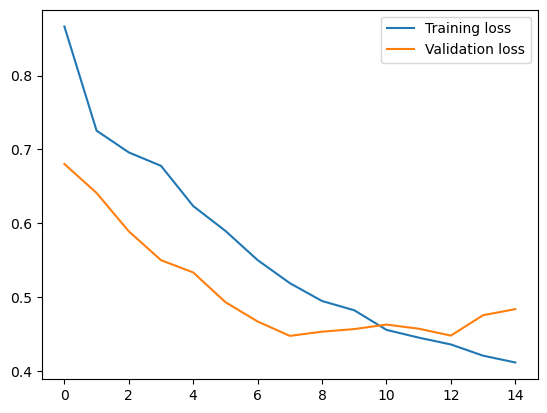

In [18]:
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.legend();

## Evaluación del modelo

In [6]:
model = load_model("../data/modelo_LSTM_flash.keras")

W0000 00:00:1767439617.659840  403116 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Reconstruction error threshold: 5.60727557725749


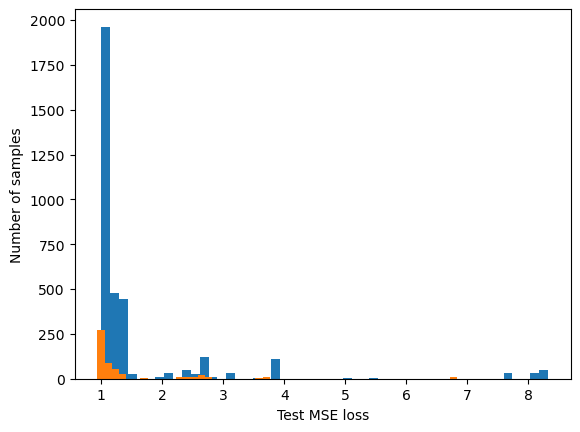

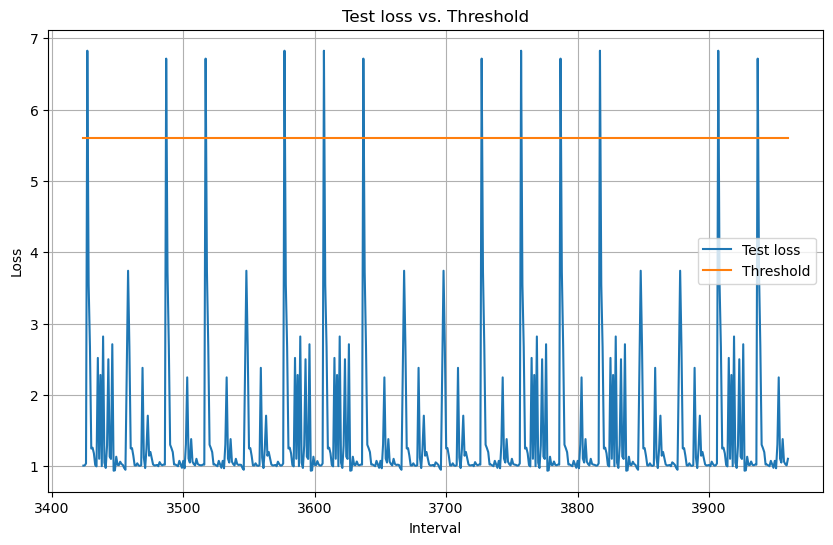

In [7]:
## Con MSE
X_train_pred = model.predict(X_train_total, verbose=0)
# Aplica MSE: 1/N sum_{1,n} (pred - real)^2
train_mse_loss = np.mean(np.square(X_train_pred - y_train_total), axis=1)

plt.hist(train_mse_loss, bins=50)
plt.xlabel("Train MSE loss")
plt.ylabel("Number of Samples")

## Cota del error de reconstrucción
threshold = np.mean(train_mse_loss) + 3 * np.std(train_mse_loss)

print(f"Reconstruction error threshold: {threshold}")

# Mismo pero con test data
X_test_pred = model.predict(X_test, verbose=0)
test_mse_loss = np.mean(np.square(X_test_pred - y_test), axis=1)

plt.hist(test_mse_loss, bins=50)
plt.xlabel("Test MSE loss")
plt.ylabel("Number of samples");

test_score_df = pd.DataFrame(test[TIME_STEPS:])
test_score_df["loss"] = test_mse_loss
test_score_df["threshold"] = threshold
test_score_df["anomaly"] = test_score_df["loss"] > test_score_df["threshold"]
test_score_df["spikes"] = test[TIME_STEPS:]["spikes"]

plt.figure(figsize=(10, 6))

plt.plot(test_score_df["interval"], test_score_df["loss"], label="Test loss")
plt.plot(test_score_df["interval"], test_score_df["threshold"], label="Threshold")

plt.xlabel("Interval")
plt.ylabel("Loss")
plt.title("Test loss vs. Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# Número de anomalías
anomalies = test_score_df.loc[test_score_df["anomaly"] == True]
anomalies.shape

(12, 5)

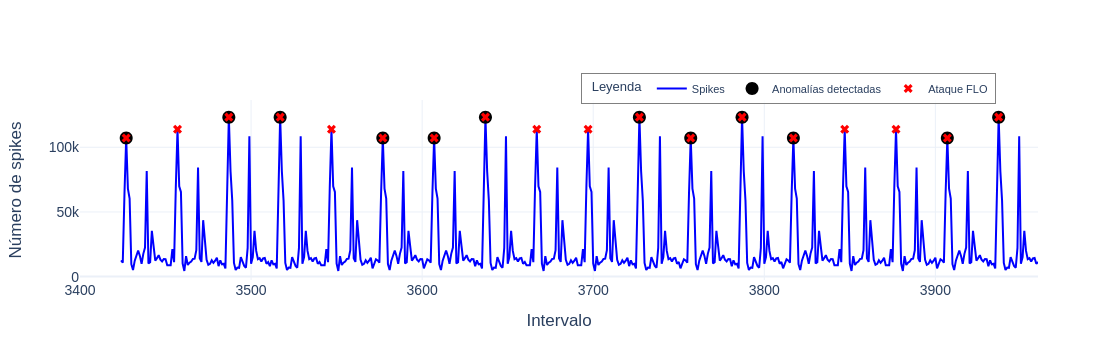

In [27]:
# -------------------------------------------------
# Datos de la serie completa y anomalías
# -------------------------------------------------
spikes_test = test_score_df["spikes"]          # valores de spikes
spikes_anomalies = anomalies["spikes"]        # spikes detectadas como anomalías
intervals_test = test_score_df["interval"]    # intervalos correspondientes

# -------------------------------------------------
# Transformar a 2D para aplicar inversa del scaler
# -------------------------------------------------
spikes_test_2d = spikes_test.values.reshape(-1, 1)
spikes_anomalies_2d = spikes_anomalies.values.reshape(-1, 1)

# Recuperar los valores originales (desnormalizar)
spikes_test_original = scaler.inverse_transform(spikes_test_2d)
spikes_anomalies_original = scaler.inverse_transform(spikes_anomalies_2d)

# -------------------------------------------------
# Definir las anomalías reales (puntos de ataque FLO)
# -------------------------------------------------
# Intervalos de las anomalías reales (cada 30 intervalos a partir de 3427)
attack_intervals = [3427, 3457, 3487, 3517, 3547, 3577, 3607, 3637, 3667, 3697, 3727, 3757, 3787, 3817, 3847, 3877, 3907, 3937]

# Obtener los valores de spikes correspondientes a estos intervalos
attack_spikes = []
attack_interval_valid = []

for interval in attack_intervals:
    # Buscar el índice del intervalo en los datos de test
    if interval in intervals_test.values:
        idx = list(intervals_test.values).index(interval)
        attack_spikes.append(spikes_test_original[idx][0])
        attack_interval_valid.append(interval)

# Convertir a arrays para usar en la gráfica
attack_spikes_array = np.array(attack_spikes)
attack_intervals_array = np.array(attack_interval_valid)

# -------------------------------------------------
# Crear figura con Plotly
# -------------------------------------------------
fig = go.Figure()

# Serie temporal completa (línea azul)
fig.add_trace(go.Scatter(
    x=intervals_test,
    y=spikes_test_original.flatten(),
    mode='lines',
    name='Spikes',
    line=dict(color='blue')
))

# Anomalías detectadas (círculo negro)
fig.add_trace(go.Scatter(
    x=anomalies["interval"],
    y=spikes_anomalies_original.flatten(),
    mode='markers',
    name='Anomalías detectadas',
    marker=dict(color='black', size=13, symbol='circle')
))

# Anomalías reales (cruz roja) - Ataques FLO
fig.add_trace(go.Scatter(
    x=attack_intervals_array,
    y=attack_spikes_array,
    mode='markers',
    name='Ataque FLO',
    marker=dict(color='red', size=8, symbol='x')
))

# -------------------------------------------------
# Configurar el diseño de la gráfica
# -------------------------------------------------
fig.update_layout(
    xaxis=dict(
        title="Intervalo",
        titlefont=dict(size=17),
        tickfont=dict(size=14),
        range=[3400, 3960]  # Ajustar rango para mejor visualización
    ),
    yaxis=dict(
        title="Número de spikes",
        titlefont=dict(size=17),
        tickfont=dict(size=14)
    ),
    legend=dict(
        title="  Leyenda",
        font=dict(size=11),
        x=0.74,
        y=1.15,
        xanchor="center",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="gray",
        borderwidth=1.0,
        orientation="h"
    ),
    template="plotly_white"
)

# Mostrar la gráfica
fig.show()

In [43]:
# a: TS donde se encuentra la anomalía dentro del csv
# l: nº intervalos/csv
# tam que tendrá el array 1-d
# PARA ESTA FUNCIÓN SUPONEMOS TW < a
def etiquetar_anomalias(a, l, tam, TW):
    etiquetas = np.zeros(tam, dtype=int)
    
    # Etiquetar las anomalías
    for i in range(tam + 1):
        if (i - a) % l == 0:
            etiquetas[i] = 1

    etiquetas = etiquetas[(TW+1):tam]
    
    return etiquetas

In [44]:
# Calcula si cada muestra es una anomalía o no basado en el umbral
predicted_labels = (test_mse_loss > threshold).astype(int)

# Etiquetas reales (0: no anomalía, 1: anomalía)
true_labels = etiquetar_anomalias(7, 30, test.shape[0]+1, 3)

In [45]:
# Calcula precision, recall y f1-score
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9888268156424581
Precision: 1.0
Recall: 0.6666666666666666
F1-score: 0.8
